# Laden des Datensatzes
In der folgenden Minichallenge will ich mit dem Datensatz `SVHN` arbeiten, der eine Sammlung von Bildern von Hausnummern von Google Street View enthält. Ziel ist es die Bilder zu klassifizieren und die Ziffern zu erkennen.

In [1]:
# Imports
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.tensorboard import SummaryWriter
import os

import matplotlib.pyplot as plt
import numpy as np

from torch.utils.data import DataLoader, Subset
from sklearn.model_selection import KFold
from sklearn.metrics import precision_score, recall_score, f1_score

# Transformieren der Bilder in Tensoren und Normalisieren
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])

c:\Users\adria\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
# Laden des SVHN-Datensatzes
train_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='train',
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.SVHN(
    root='./data',
    split='test',
    download=True,
    transform=transform
)

print(len(train_dataset))
print(len(test_dataset))

Using downloaded and verified file: ./data\train_32x32.mat
Using downloaded and verified file: ./data\test_32x32.mat
73257
26032


In [3]:
# DataLoader erstellen
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

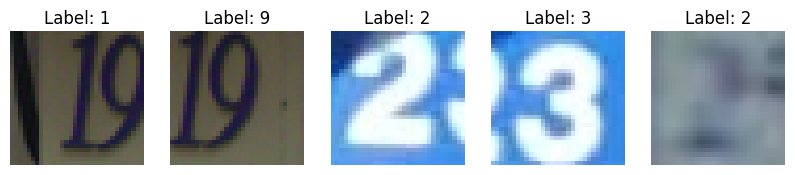

In [4]:
# Bilder anzeigen mit ihren Labels
plt.figure(figsize=(10, 2))

for i in range(5):
    image, label = train_dataset[i]

    # Denormalisieren für die Anzeige
    image = image.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5 

    plt.subplot(1, 5, i + 1)
    plt.imshow(image)
    plt.title(f'Label: {label}')
    plt.axis('off')

plt.show()

# Explorative Datenanalyse
Zuerst soll der Datensatz kurz analysiert werden, um ein besseres Verständnis für die Daten zu bekommen. Dazu wird die Anzahl der Bilder, die Verteilung der Klassen und details in den Bildern untersucht.

In [5]:
# Anzahl der Bilder und Bildgrösse
print("Anzahl Trainingsbilder:", len(train_dataset))
print("Anzahl Testbilder:", len(test_dataset))

image, label = train_dataset[0]

print("Bildgrösse:", image.shape)

Anzahl Trainingsbilder: 73257
Bildgrösse: torch.Size([3, 32, 32])


## Anzahl Bilder
Der Datensatz enthält insgesamt 73.257 Bilder im Trainingsset und 26.032 Bilder im Testset. Die Bilder haben dabei eine Grösse von 32x32 Pixeln und sind in RGB-Farben dargestellt.

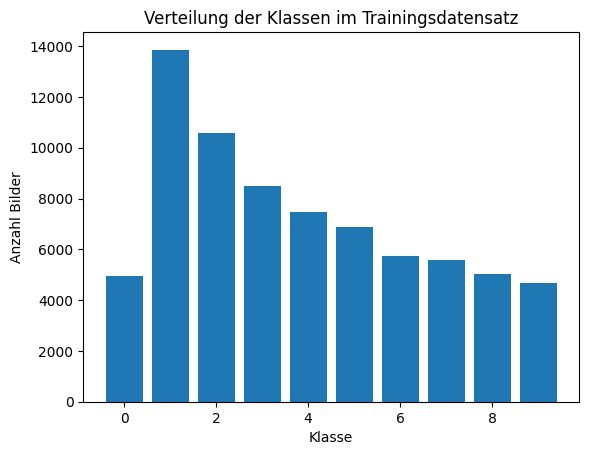

In [6]:
# Klassenverteilung
labels = [train_dataset[i][1] for i in range(len(train_dataset))]
unique_labels, counts = np.unique(labels, return_counts=True)

plt.bar(unique_labels, counts)
plt.xlabel('Klasse')
plt.ylabel('Anzahl Bilder')
plt.title('Verteilung der Klassen im Trainingsdatensatz')
plt.show()

## Klassenverteilung
In der Klassenverteilung sieht man, dass die Klasse 1 am häufigsten vorkommt und danach absteigend die anderen Klassen. Dies ergibt durchaus Sinn, wenn man bedenkt woher die Bilder stammen. Hausnummern beginnen meistens bei 1 und bei danach werden die Zahlen immer seltener, da es zwar oft Hausnummern mit 11 oder 12 gibt aber selten eine 99 oder 100. Diese Imbalance könnte sich negativ auf die Performance des Modells auswirken. Es könnte deshalb im späteren verlauf auch sinnvoll sein mehr auf Metriken wie den F1-Score zu achten, da dieser die Imbalance besser berücksichtigt als die Accuracy.

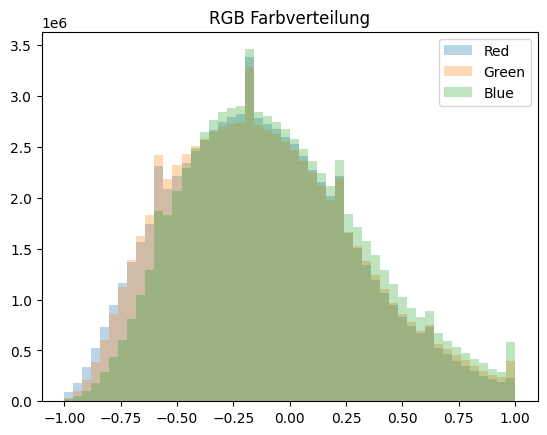

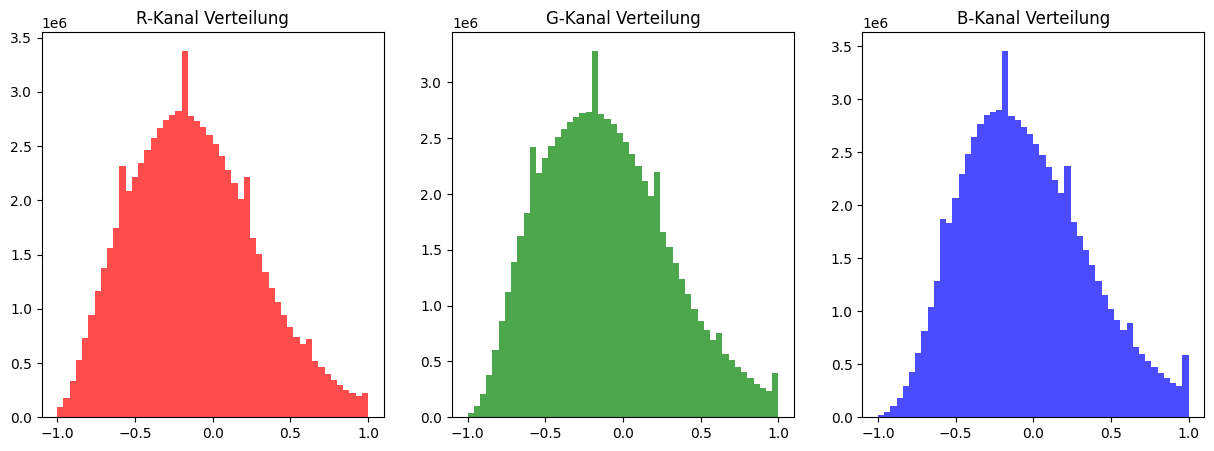

In [7]:
# Farbverteilung
all_pixels = []

for i in range(len(train_dataset)):
    img, _ = train_dataset[i]
    all_pixels.append(img.numpy())

all_pixels = np.concatenate(all_pixels, axis=1)

r = all_pixels[0].flatten()
g = all_pixels[1].flatten()
b = all_pixels[2].flatten()

plt.hist(r, bins=50, alpha=0.3, label="Red")
plt.hist(g, bins=50, alpha=0.3, label="Green")
plt.hist(b, bins=50, alpha=0.3, label="Blue")

plt.legend()
plt.title("RGB Farbverteilung")
plt.show()

# Detailplots für jede Farbe
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.hist(r, bins=50, color='red', alpha=0.7)
plt.title("R-Kanal Verteilung")
plt.subplot(1, 3, 2)
plt.hist(g, bins=50, color='green', alpha=0.7)
plt.title("G-Kanal Verteilung")
plt.subplot(1, 3, 3)
plt.hist(b, bins=50, color='blue', alpha=0.7)
plt.title("B-Kanal Verteilung")
plt.show()

## Farbverteilung
Die Bilder sind in RGB-Farben dargestellt, was bedeutet, dass jedes Bild aus drei Kanälen besteht: Rot, Grün und Blau. In der Darstellung der einzelnen Kanäle ist gut zu sehen, dass diese auf allen Kanälen relativ gleichmässig verteilt sind. Es gibt keine auffälligen Farbdominanzen.

## Identifizierte Probleme
- Es gibt eine Klassenimbalance, da die Klasse 1 am häufigsten vorkommt und danach absteigend die anderen Klassen. Dies könnte sich negativ auf die Performance des Modells auswirken.
- Einige Bilder beinhalten mehrere Ziffern. Diese sind dann etwas anders Zentriert und danach jeweils einzel gelabelt. So ist Beispielsweise ein Bild mit einer 19 zuerst mit einer 1 gelabelt und danach mit einer 9. Dies könnte es dem Modell erschweren die Ziffern zu erkennen, da diese nicht immer an der selben Stelle im Bild sind.
- Da die Bilder von Street View stammen, gibt es teilweise auch Bilder mit schlechter Qualität, beispielsweise durch schlechte Beleuchtung oder Unschärfe. Dies könnte es dem Modell erschweren die Ziffern zu erkennen, da diese teilweise schwer zu erkennen sind.

# Definieren der Evaluation Metriken
Um die Performance des Modells zu bewerten, werden folgende Metriken definiert:

Accuracy: Die Accuracy gibt an, wie viele der vorhergesagten Klassen korrekt sind.  
Formel: $\text{Accuracy} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Gesamtanzahl der Vorhersagen}}$

Precision: Die Precision gibt an, wie viele der vorhergesagten Klassen tatsächlich zur jeweiligen Klasse gehören.  
Formel: $\text{Precision} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Anzahl der vorhergesagten Klassen}} = \frac{TP}{TP + FP}$

Recall: Der Recall gibt an, wie viele der tatsächlichen Klassen korrekt vorhergesagt wurden.  
Formel: $\text{Recall} = \frac{\text{Anzahl der korrekt vorhergesagten Klassen}}{\text{Anzahl der tatsächlichen Klassen}} = \frac{TP}{TP + FN}$

F1-Score: Der F1-Score ist das Mittel von Precision und Recall und gibt eine ausgewogene Bewertung der Performance des Modells.  
Formel: $\text{F1-Score} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$

# Deep Learning Pipeline

## Baslinemodellierung
Das Baselinemodell besteht aus einem Convolutional Network, dass Zuerst ein Convolutional Layer mit 32 Filtern und einer Kernelgrösse von 3x3 hat, gefolgt von einer ReLU-Aktivierungsfunktion und einer einfachen Max-Pooling-Schicht. Danach folgt ein weiteres Convolutional Layer mit 64 Filtern und einer Kernelgrösse von 3x3, gefolgt von einer ReLU-Aktivierungsfunktion und einer Max-Pooling-Schicht. Die beiden Convolutional Layer haben jeweils ein Padding von 1, um die räumlichen Dimensionen der Bilder beizubehalten.

Im Anschluss folgt ein Fully Connected Layer mit 128 Neuronen und einer ReLU-Aktivierungsfunktion. Im Forward wird dann zuerst das Convolutional Layer und danach das Fully Connected Layer aufgerufen. Dies könnte auch gemeinsam in der Initialisierung gemacht werden, ich selbst finde es aber in dieser Form übersichtlicher.

In [8]:
class BaselineCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

## Definieren des Trainingsprozesses
In `train_epoch` wird der Trainingsprozess definiert. Als eingabe muss das Modell, der Loader, der Optimizer sowie die Lossfunktion übergeben werden. Zudem wird auch das Gerät übergeben, damit die Daten und das Modell auf die GPU geladen werden können. In der Funktion werden dann jeweils die einzelnen Batches durchlaufen, die Daten auf die GPU geladen, danach wird ein Forward Pass gemacht. Danach wird der Loss berechnet, und ein Backward Pass gemacht, um die Gewichte zu aktualisieren. Am Ende der Funktion wird die durchschnittliche Loss über alle Batches zurückgegeben und die Accuracy über alle Batches berechnet und zurückgegeben.

In [ ]:
def train_epoch(model, loader, optimizer, criterion, device, writer=None, epoch=0):

    model.train()       # Model wird in Trainingsmodus versetzt

    total_loss = 0
    correct = 0
    total = 0

    for images, labels in loader:       # Durchlaufen jedes Batches

        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()           # Alte Gradienten werden zurückgesetzt auf 0

        outputs = model(images)         # Forward Pass durch das Modell

        loss = criterion(outputs, labels)   # Berechnen des Loss

        loss.backward()         # Backward Pass: Berechnen der Gradienten
        optimizer.step()        # Updaten der Gewichte

        total_loss += loss.item()   # Loss zum totalen Loss hinzufügen

        preds = outputs.argmax(1)   # Vorhersagen durch Auswahl der Klasse mit höchster Wahrscheinlichkeit

        correct += (preds == labels).sum().item()   # Anzahl korrekter Vorhersagen
        total += labels.size(0)     # Gesamtanzahl der Bilder

    acc = correct / total       # Berechnen der Genauigkeit

    if writer:
        writer.add_scalar('Train/Loss', total_loss/len(loader), epoch)
        writer.add_scalar('Train/Accuracy', acc, epoch)

    return total_loss/len(loader), acc

## Definieren des Evaluationsprozesses
In `evaluate` wird der Evaluationsprozess definiert. Als eingabe muss wie beim training auch das Modell, der Loader, die Lossfunktion und das Gerät übergeben werden. In der Funktion werden dann die einzelnen Batches durchlaufen, die Daten auf die GPU geladen, danach wird ein Forward Pass gemacht. Der Unterschied zum Training ist, dass hier kein Backward Pass gemacht wird und auch keine Gewichte aktualisiert werden. Aber es werden zusätzlich zum Loss und der Accuracy auch die Precision, der Recall und der F1-Score berechnet und zurückgegeben. Am Ende der Funktion wird die durchschnittliche Loss über alle Batches zurückgegeben und die Accuracy, Precision, Recall und F1-Score über alle Batches berechnet und zurückgegeben. 

In [ ]:
def evaluate(model, loader, criterion, device, writer=None, epoch=0):

    model.eval()            # Model wird in Evaluationsmodus versetzt

    total_loss = 0
    correct = 0
    total = 0

    all_preds = []   # Liste für alle Vorhersagen
    all_labels = []  # Liste für alle wahren Labels

    with torch.no_grad():   # Deaktivieren der Gradientenberechnung

        for images, labels in loader:

            images, labels = images.to(device), labels.to(device)

            outputs = model(images)     # Forward Pass durch das Modell

            loss = criterion(outputs, labels)   # Berechnen des Loss

            total_loss += loss.item()

            preds = outputs.argmax(1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())   # Vorhersagen sammeln für spätere Analyse
            all_labels.extend(labels.cpu().numpy())  # Wahre Labels sammeln für spätere Analyse

    acc = correct / total

    # Precision, Recall, F1-Score
    precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
    f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

    if writer:
        writer.add_scalar('Test/Loss', total_loss/len(loader), epoch)
        writer.add_scalar('Test/Accuracy', acc, epoch)
        writer.add_scalar('Test/Precision', precision, epoch)
        writer.add_scalar('Test/Recall', recall, epoch)
        writer.add_scalar('Test/F1', f1, epoch)

    return total_loss/len(loader), acc, precision, recall, f1

## Model Setup
Nachfolgend wird das Model definiert. Zuerst wird die GPU als Device eingeführt. Das CNN wird erstellt, die Loss Funktion definiert, ein SGD-Optimizer mit bestimmter learning Rate erstellt

In [11]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

model = BaselineCNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(model.parameters(), lr=0.01)

cuda


In [12]:
# TensorBoard Writer erstellen
log_dir = "./runs/svhn-baseline"
writer = SummaryWriter(log_dir=log_dir)

print(f"TensorBoard logs werden gespeichert in: {log_dir}")

TensorBoard logs werden gespeichert in: ./runs/svhn-baseline


## Overfitting
Im ersten Teil wird das Modell nur auf einem einzigen Bild trainiert, um zu sehen, ob es in der Lage ist, dieses Bild korrekt zu klassifizieren.

Im Anschluss soll das gleich noch mit einem kleinen Datensatz von einem Batch von 32 Bildern gemacht werden. Auch hier ist das Ziel, dass das Modell overfittet und die Bilder korrekt klassifiziert.

OVERFITTING TEST: Ein Sample


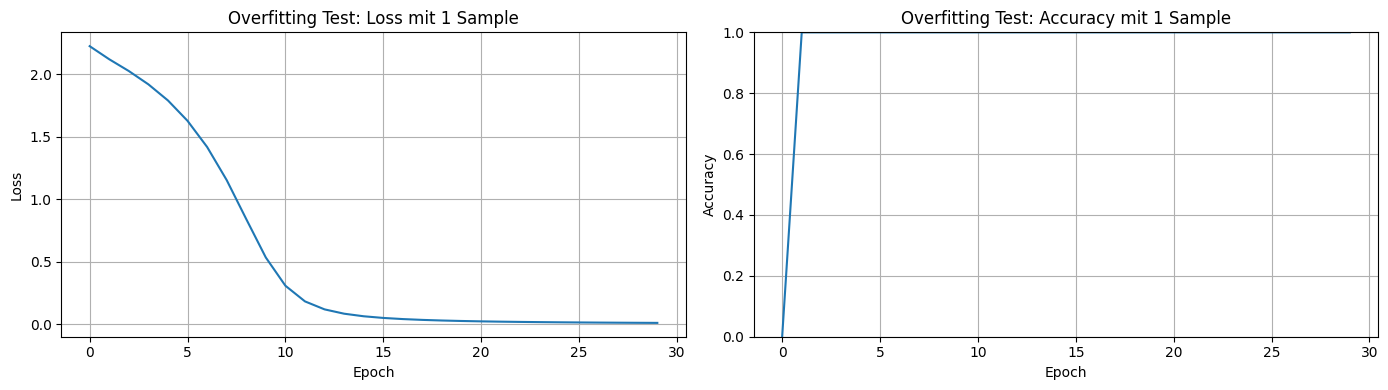

Finaler Loss mit 1 Sample: 0.0102
Finale Accuracy mit 1 Sample: 1.0000


In [13]:
# Overfit Test: Trainiere nur auf einem Sample
print("=" * 50)
print("OVERFITTING TEST: Ein Sample")
print("=" * 50)

model_test = BaselineCNN().to(device)
optimizer_test = optim.SGD(model_test.parameters(), lr=0.01)

# Einen Sample nehmen
sample_image, sample_label = train_dataset[0]
sample_image = sample_image.unsqueeze(0)
sample_label = torch.tensor([sample_label])

# DataLoader für das Sample erstellen
from torch.utils.data import TensorDataset
sample_dataset = TensorDataset(sample_image, sample_label)
sample_loader = DataLoader(sample_dataset, batch_size=1, shuffle=False)

# Mit diesem einen Sample für viele Epochen trainieren
test_epochs = 30
test_losses = []
test_accs = []

for epoch in range(test_epochs):
    loss, acc= train_epoch(model_test, sample_loader, optimizer_test, criterion, device)
    test_losses.append(loss)
    test_accs.append(acc)

# Visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_losses)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Overfitting Test: Loss mit 1 Sample")
axes[0].grid()

axes[1].plot(test_accs)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Overfitting Test: Accuracy mit 1 Sample")
axes[1].grid()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"Finaler Loss mit 1 Sample: {test_losses[-1]:.4f}")
print(f"Finale Accuracy mit 1 Sample: {test_accs[-1]:.4f}")


OVERFITTING TEST: Ein Batch


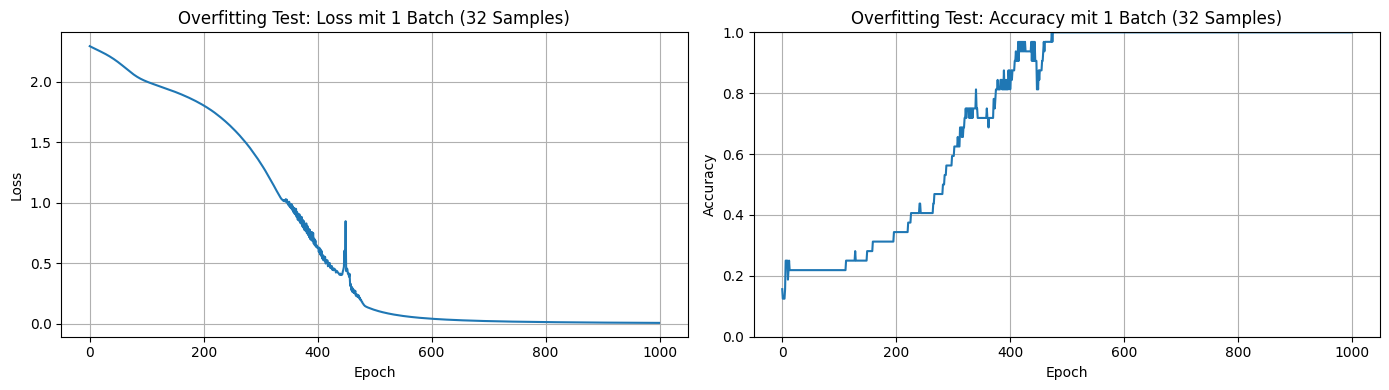

Finaler Loss mit 1 Batch: 0.0075
Finale Accuracy mit 1 Batch: 1.0000
Basisfunktionalität bestätigt: Model kann Daten überfitten


In [14]:
# Overfit Test: Trainiere nur auf einem Batch von 32 Samples
print("\n" + "=" * 50)
print("OVERFITTING TEST: Ein Batch")
print("=" * 50)

model_test = BaselineCNN().to(device)
optimizer_test = optim.SGD(model_test.parameters(), lr=0.01)
criterion_test = nn.CrossEntropyLoss()

# Einen Batch nehmen
batch_images, batch_labels = next(iter(DataLoader(train_dataset, batch_size=32)))

# DataLoader für den Batch erstellen
batch_dataset = TensorDataset(batch_images, batch_labels)
batch_loader = DataLoader(batch_dataset, batch_size=32, shuffle=False)

test_epochs = 1000
test_losses_batch = []
test_accs_batch = []

for epoch in range(test_epochs):
    loss, acc = train_epoch(model_test, batch_loader, optimizer_test, criterion, device)
    test_losses_batch.append(loss)
    test_accs_batch.append(acc)

# Visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(test_losses_batch)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Overfitting Test: Loss mit 1 Batch (32 Samples)")
axes[0].grid()

axes[1].plot(test_accs_batch)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Overfitting Test: Accuracy mit 1 Batch (32 Samples)")
axes[1].grid()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"Finaler Loss mit 1 Batch: {test_losses_batch[-1]:.4f}")
print(f"Finale Accuracy mit 1 Batch: {test_accs_batch[-1]:.4f}")
print("Basisfunktionalität bestätigt: Model kann Daten überfitten")

# Hyperparameter Tuning

Systematische Evaluation von Learning Rates und Batch Sizes ohne automatische Hyperparameter-Suche.

## Parameter Grid:
Als Hyperparameter werden folgende Werte definiert:
- Learning Rates: [0.1, 0.01, 0.001]
- Batch Sizes: [32, 64, 128]
- Training: 30 Epochen pro Kombination
- Evaluation auf Testdatensatz

In [ ]:
# Hyperparameter Tuning

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 64, 128]
epochs = 30

# Dictionary für Ergebnisse speichern
results = {}

for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\nTraining mit LR={lr}, Batch Size={bs}")
        print("-" * 40)
        
        # DataLoader mit aktueller Batch Size
        train_loader_tuning = DataLoader(
            train_dataset, 
            batch_size=bs, 
            shuffle=True
        )
        test_loader_tuning = DataLoader(
            test_dataset, 
            batch_size=bs, 
            shuffle=False
        )
        
        # Neues Modell
        model = BaselineCNN().to(device)
        optimizer = optim.SGD(model.parameters(), lr=lr)
        
        # Training
        train_losses = []
        train_accs = []
        test_losses = []
        test_accs = []
        test_precisions = []
        test_recalls = []
        test_f1s = []
        
        for epoch in range(epochs):
            train_loss, train_acc = train_epoch(
                model, train_loader_tuning, optimizer, criterion, device,
                writer=writer, epoch=epoch
            )
            test_loss, test_acc, test_precision, test_recall, test_f1 = evaluate(
                model, test_loader_tuning, criterion, device,
                writer=writer, epoch=epoch
            )
            
            train_losses.append(train_loss)
            train_accs.append(train_acc)
            test_losses.append(test_loss)
            test_accs.append(test_acc)
            test_precisions.append(test_precision)
            test_recalls.append(test_recall)
            test_f1s.append(test_f1)

            if epoch % 2 == 0:
                print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={test_acc:.4f}, Test Precision={test_precision:.4f}, Test Recall={test_recall:.4f}, Test F1={test_f1:.4f}")
        
        # Speichern
        results[(lr, bs)] = {
            'train_loss': train_losses,
            'train_acc': train_accs,
            'test_loss': test_losses,
            'test_acc': test_accs,
            'test_precisions': test_precisions,
            'test_recalls': test_recalls,
            'test_f1s': test_f1s
        }

print("\n" + "=" * 50)
print("TUNING ABGESCHLOSSEN")
print("=" * 50)


Training mit LR=0.1, Batch Size=32
----------------------------------------
Epoch 0: Train Acc=0.6785, Test Acc=0.8401, Precision=0.8487, Recall=0.8401, F1=0.8398
Epoch 2: Train Acc=0.9119, Test Acc=0.8822, Precision=0.8867, Recall=0.8822, F1=0.8819
Epoch 4: Train Acc=0.9427, Test Acc=0.8815, Precision=0.8839, Recall=0.8815, F1=0.8810
Epoch 6: Train Acc=0.9619, Test Acc=0.8868, Precision=0.8880, Recall=0.8868, F1=0.8869
Epoch 8: Train Acc=0.9741, Test Acc=0.8778, Precision=0.8836, Recall=0.8778, F1=0.8783
Epoch 10: Train Acc=0.9794, Test Acc=0.8966, Precision=0.8969, Recall=0.8966, F1=0.8965
Epoch 12: Train Acc=0.9844, Test Acc=0.8906, Precision=0.8917, Recall=0.8906, F1=0.8906
Epoch 14: Train Acc=0.9825, Test Acc=0.8861, Precision=0.8884, Recall=0.8861, F1=0.8864
Epoch 16: Train Acc=0.9857, Test Acc=0.8898, Precision=0.8907, Recall=0.8898, F1=0.8899
Epoch 18: Train Acc=0.9845, Test Acc=0.8830, Precision=0.8845, Recall=0.8830, F1=0.8823
Epoch 20: Train Acc=0.9914, Test Acc=0.8879, Pre

In [21]:
# Ergebnisse als Tabelle anzeigen
print("\nErgebnisse Zusammenfassung:")
print("-" * 130)
print(f"{'LR':<10} {'BS':<10} {'Final Test Acc':<20} {'Last 10 Test Acc':<20} {'Final Precision':<20} {'Final Recall':<20} {'Final F1-Score':<20}")
print("-" * 130)

for (lr, bs), res in sorted(results.items()):
    final_acc = res['test_acc'][-1]
    final_precision = res['test_precisions'][-1]
    final_recall = res['test_recalls'][-1]
    final_f1 = res['test_f1s'][-1]
    
    last_10_acc = np.mean(res['test_acc'][-10:])

    
    print(f"{lr:<10} {bs:<10} {final_acc:<20.4f} {last_10_acc:<20.4f} {final_precision:<20.4f} {final_recall:<20.4f} {final_f1:<20.4f}")


Ergebnisse Zusammenfassung:
----------------------------------------------------------------------------------------------------------------------------------
LR         BS         Final Test Acc       Last 10 Test Acc     Final Precision      Final Recall         Final F1-Score      
----------------------------------------------------------------------------------------------------------------------------------
0.001      32         0.8464               0.8146               0.8485               0.8464               0.8467              
0.001      64         0.7701               0.6849               0.7803               0.7701               0.7710              
0.001      128        0.1961               0.1959               0.0767               0.1961               0.0647              
0.01       32         0.8804               0.8820               0.8843               0.8804               0.8809              
0.01       64         0.8684               0.8708               0.8713    

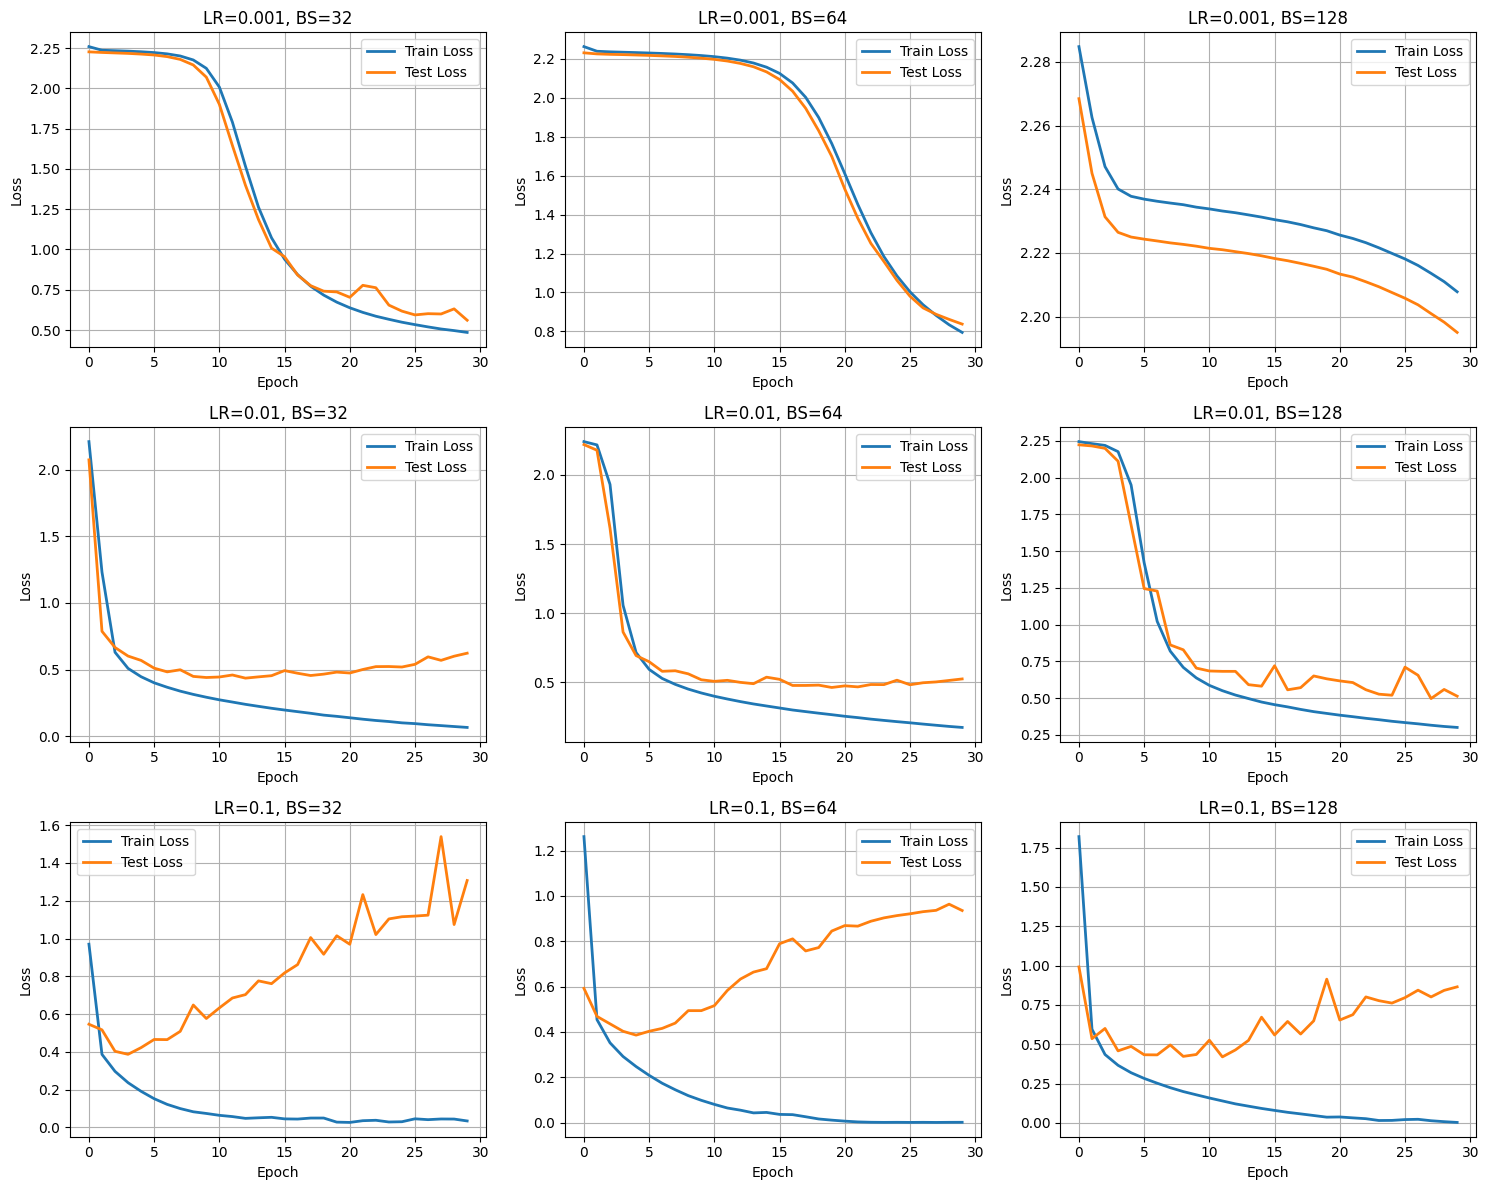

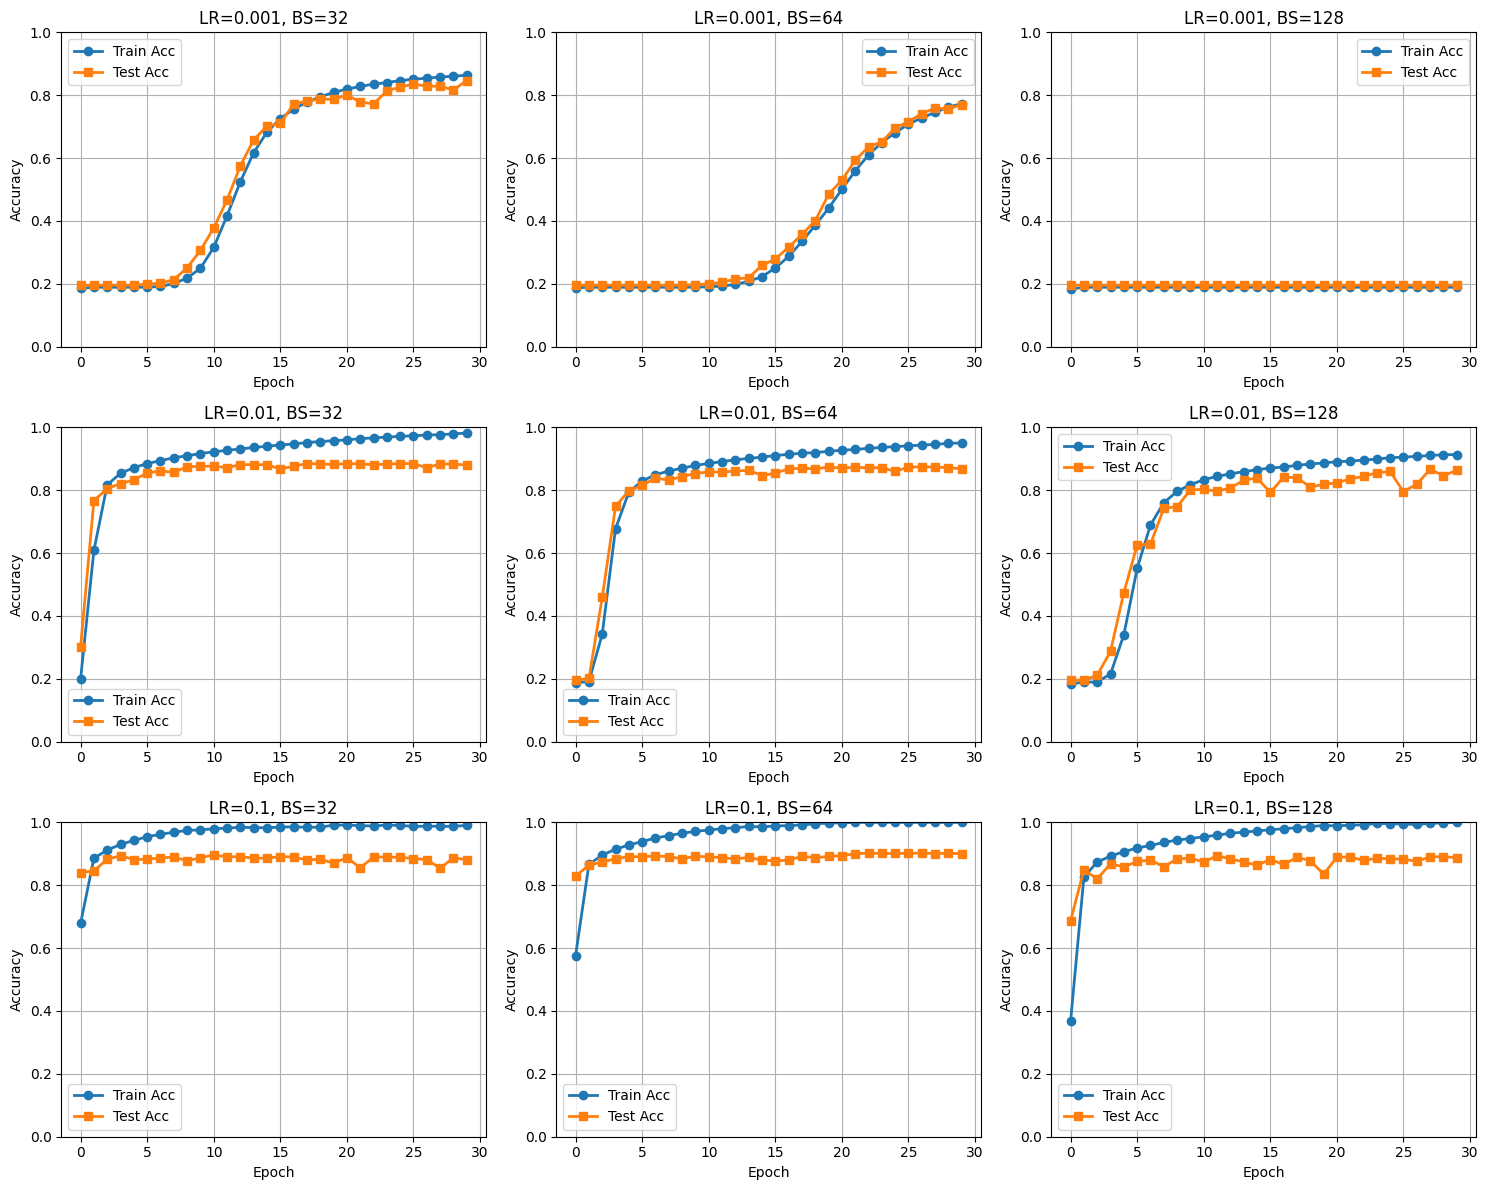

In [22]:
# Lernkurven für alle Kombinationen plotten
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (lr, bs) in enumerate(sorted(results.keys())):
    res = results[(lr, bs)]
    
    ax = axes[idx]
    epochs_range = range(len(res['train_loss']))
    
    ax.plot(epochs_range, res['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(epochs_range, res['test_loss'], label='Test Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.set_title(f'LR={lr}, BS={bs}')
    ax.legend()
    ax.grid()

plt.tight_layout()
plt.savefig('learning_curves_loss.png', dpi=150)
plt.show()

# Genauigkeitskurven
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for idx, (lr, bs) in enumerate(sorted(results.keys())):
    res = results[(lr, bs)]
    
    ax = axes[idx]
    epochs_range = range(len(res['train_acc']))
    
    ax.plot(epochs_range, res['train_acc'], label='Train Acc', linewidth=2, marker='o')
    ax.plot(epochs_range, res['test_acc'], label='Test Acc', linewidth=2, marker='s')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.set_title(f'LR={lr}, BS={bs}')
    ax.legend()
    ax.grid()
    ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('learning_curves_accuracy.png', dpi=150)
plt.show()

## Auswertung der Hyperparameter:
Es zeigt sich, dass die Lernrate von 0.001 noch viele weitere Epochen benötigt um zu konvergieren. Je grösser dazu noch die Batch Size ist, desto schlechter ist die Performance. Dies könnte daran liegen, dass es noch weniger Updates gibt, da die Batch Size grösser ist. Was man aber gerade im Zweiten Plot sieht, ist dass sich die Accuracy vom Trainings und Testdatensatz nicht grösser unterscheidet.

Bei den beiden grösseren Lernraten konvergiert der Loss auf dem Trainingsdatensatz deutlich besser, auch wird hier eine hohe Accuracy erreicht, welche teilweise fast 100% erreicht. Auf den Testdaten sieht man aber, dass kein Modell die Accuracy über 90% bringt. Zudem sieht man auch, dass die Lossfunktion auf den Testdaten meistens sogar ansteigt und nicht konvergiert. Dies könnte ein Anzeichen dafür sein, dass die Modelle überfitten. Was auffält, ist das die Accuracy auf den Testdaten stabil bleibst aber die Lossfunktion ansteigt. Dies könnte daran liegen, dass die Modelle zwar die Bilder korrekt klassifizieren, aber mit einer sehr hohen Unsicherheit, was sich in einem hohen Loss widerspiegelt oder dass die Modelle die falsch klassifizierten Bilder nicht nur ein bisschen falsch klassifizieren, sondern komplett falsch, was sich wiederum auch in einem hohen Loss widerspiegelt.



In [25]:
# Beste Parameter finden
best_params = max(results.items(), key=lambda x: x[1]['test_acc'])
best_lr, best_bs = best_params[0]
best_result = best_params[1]

print("\n" + "=" * 50)
print("BESTE HYPERPARAMETER")
print("=" * 50)
print(f"Learning Rate: {best_lr}")
print(f"Batch Size: {best_bs}")
print(f"Finale Test Accuracy: {best_result['test_acc'][-1]:.4f}")
print(f"Accuracy (letzte 10 Epochen): {np.mean(best_result['test_acc'][-10:]):.4f}")
print(f"Finale Precision: {best_result['test_precisions'][-1]:.4f}")
print(f"Finale Recall: {best_result['test_recalls'][-1]:.4f}")
print(f"Finale F1-Score: {best_result['test_f1s'][-1]:.4f}")


BESTE HYPERPARAMETER
Learning Rate: 0.1
Batch Size: 32
Finale Test Accuracy: 0.8808
Accuracy (letzte 10 Epochen): 0.8799
Finale Precision: 0.8830
Finale Recall: 0.8808
Finale F1-Score: 0.8812


## Beste Hyperparameter-Kombination:
Die beste Hyperparameter-Kombination wird hier ausgewählt um im anschluss einen K-Fold Cross Validation zu machen. Dabei wird als Kriterium die Accuracy auf den zehn letzten Epochen genommen, um eine gewisse Stabilität zu gewährleisten. Es ist mir aber auch bewusst, dass es sicherlich noch bessere Hyperparameter gäbe, wenn die Epochenzahl erhöht werden würde und noch weitere Kombinationen ausprobiert werden würden. Aus zeitgründen gebe ich mich aber mit dieser Kombination für das Baseline Modell zufrieden und werde später noch versuchen die Hyperparameter zu optimieren, um die Performance zu verbessern.

# Statistische Fehleranalyse mit K-Fold Cross-Validation
Hier soll geprüft werden, ob die Ergebnisse des Modells stabil sind oder ob sie stark von der Aufteilung der Daten abhängen. Dazu wird K-Fold Cross-Validation verwendet, um das Modell auf verschiedenen Datenaufteilungen zu trainieren und zu evaluieren. Ich arbeite dabei mit 5 Folds.

In [26]:
print("\n" + "=" * 50)
print("K-Fold Cross-Validation (mit besten Parametern)")
print("=" * 50)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_accuracies = []
cv_results = []

fold = 0
for train_idx, val_idx in kf.split(train_dataset):
    fold += 1
    print(f"\nFold {fold}/5")
    print("-" * 40)
    
    train_subset = Subset(train_dataset, train_idx)
    val_subset = Subset(train_dataset, val_idx)
    
    train_loader_cv = DataLoader(train_subset, batch_size=best_bs, shuffle=True)
    val_loader_cv = DataLoader(val_subset, batch_size=best_bs, shuffle=False)
    
    model = BaselineCNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=best_lr)
    
    fold_train_accs = []
    fold_val_accs = []
    
    for epoch in range(30):
        train_loss, train_acc = train_epoch(
            model, train_loader_cv, optimizer, criterion, device
        )
        val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
            model, val_loader_cv, criterion, device
        )
        
        fold_train_accs.append(train_acc)
        fold_val_accs.append(val_acc)
    
    final_val_acc = fold_val_accs[-1]
    cv_accuracies.append(final_val_acc)
    
    cv_results.append({
        'fold': fold,
        'train_accs': fold_train_accs,
        'val_accs': fold_val_accs,
        'final_acc': final_val_acc
    })
    
    print(f"Finale Val Accuracy: {final_val_acc:.4f}")
    print(f"Finale Val Precision: {val_precision:.4f}")
    print(f"Finale Val Recall: {val_recall:.4f}")
    print(f"Finale Val F1-Score: {val_f1:.4f}")

# Statistisch Fehler berechnen
mean_acc = np.mean(cv_accuracies)
std_acc = np.std(cv_accuracies)
ci_95 = 1.96 * std_acc / np.sqrt(len(cv_accuracies))

print("\n" + "=" * 50)
print("CROSS-VALIDATION ERGEBNISSE")
print("=" * 50)
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Std Abweichung: {std_acc:.4f}")
print(f"95% Konfidenzintervall: [{mean_acc - ci_95:.4f}, {mean_acc + ci_95:.4f}]")
print(f"\nAccuracies pro Fold: {[f'{acc:.4f}' for acc in cv_accuracies]}")


K-Fold Cross-Validation (mit besten Parametern)

Fold 1/5
----------------------------------------
Finale Val Accuracy: 0.8911
Finale Val Precision: 0.8920
Finale Val Recall: 0.8911
Finale Val F1-Score: 0.8910

Fold 2/5
----------------------------------------
Finale Val Accuracy: 0.8954
Finale Val Precision: 0.8955
Finale Val Recall: 0.8954
Finale Val F1-Score: 0.8952

Fold 3/5
----------------------------------------
Finale Val Accuracy: 0.8959
Finale Val Precision: 0.8961
Finale Val Recall: 0.8959
Finale Val F1-Score: 0.8958

Fold 4/5
----------------------------------------
Finale Val Accuracy: 0.8812
Finale Val Precision: 0.8835
Finale Val Recall: 0.8812
Finale Val F1-Score: 0.8817

Fold 5/5
----------------------------------------
Finale Val Accuracy: 0.8949
Finale Val Precision: 0.8957
Finale Val Recall: 0.8949
Finale Val F1-Score: 0.8949

CROSS-VALIDATION ERGEBNISSE
Mean Accuracy: 0.8917
Std Abweichung: 0.0055
95% Konfidenzintervall: [0.8869, 0.8965]

Accuracies pro Fold: ['0.

C:\Users\adria\AppData\Local\Temp\ipykernel_24300\1259489082.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot(cv_accuracies, labels=['K-Fold CV'])


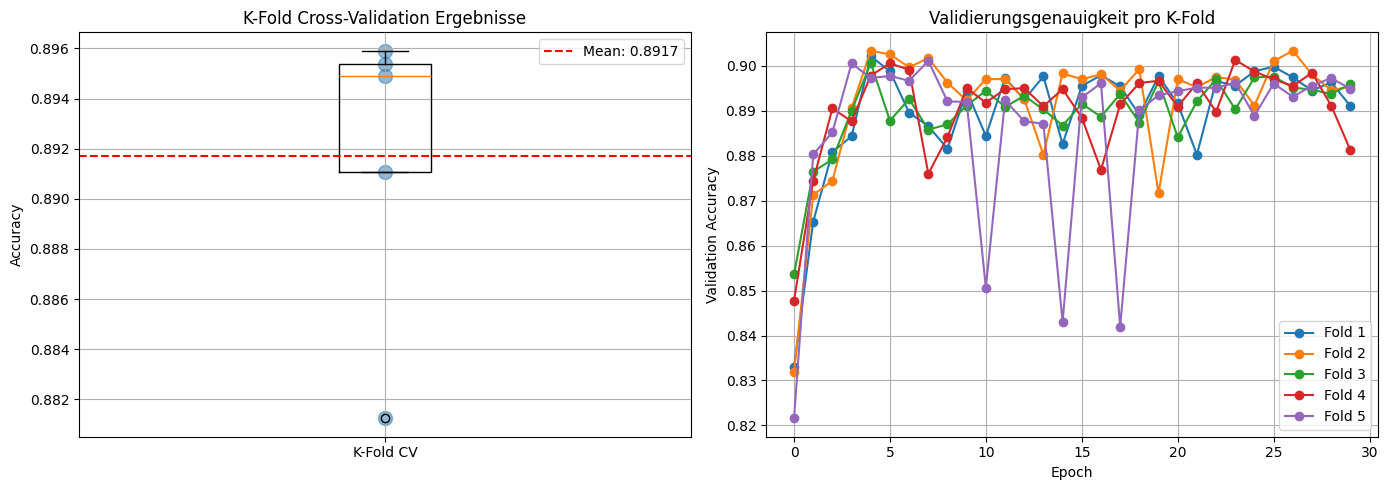

Alle Tensorboard Logs abgeschlossen!


In [27]:
# K-Fold Ergebnisse visualisieren
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot
ax1 = axes[0]
ax1.boxplot(cv_accuracies, labels=['K-Fold CV'])
ax1.scatter([1]*len(cv_accuracies), cv_accuracies, alpha=0.5, s=100)
ax1.axhline(y=mean_acc, color='r', linestyle='--', label=f'Mean: {mean_acc:.4f}')
ax1.set_ylabel('Accuracy')
ax1.set_title('K-Fold Cross-Validation Ergebnisse')
ax1.legend()
ax1.grid()

# Lernkurven pro Fold
ax2 = axes[1]
for result in cv_results:
    epochs_range = range(len(result['val_accs']))
    ax2.plot(epochs_range, result['val_accs'], marker='o', label=f"Fold {result['fold']}")

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Validation Accuracy')
ax2.set_title('Validierungsgenauigkeit pro K-Fold')
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.savefig('cross_validation_results.png', dpi=150)
plt.show()

writer.close()
print("Alle Tensorboard Logs abgeschlossen!")

## Beuurteilung der K-Fold Cross-Validation:
Es ist in den beiden Plots zu sehen, dass die Performance des Modells auf den verschiedenen Folds relativ stabil ist. Es gibt zwar leichte Unterschiede in der Accuracy aber diese sind nicht sehr gross. Einzig verwunderlich ist, dass es an manchen Stellen kleinere Spikes in gewissen Folds gibt. Diese könnten mir kleineren Lernraten vielleicht behoben werden, da diese vielleicht stabiler konvergieren würden.

## Interpretation des Baselinemodells

Das Modell konnte schnell definiert werden und besteht aus einem CNN mit zwei Convolutionalen Layern, welche jeweils von einer ReLU und einem Maxpooling gefolgt werden. Das Modell Overfittet gut auf einem einzelnen Bild und auch auf einem einzelnen Batch.  Im Training mit verschiedenen Lernraten und Batchsizes ist zu sehen, dass das Modell bei einer kleinen Lernrate noch deutlich mehr Epochen bräuchte. Auffallend ist aber auch, dass bei einer Hohen Lernrate der Loss beim Testset nach wenigen Epochen ansteigt. Und auch die Accuracy nicht sonderlich verbessert wird nach den ersten par Trainingsepochen.

In der K-Fold Crossvalidation sieht man zudem, dass zwar alle einzelnen Folds ungefähr gleich gut trainieren, jedoch ist auch auffallend, dass die Accuracy an gewissen Punkten enorm schwankt während des Trainings. Auch wurde in allen Trainings eine Maximale Accuracy von 0.9 nicht überschritten. Dies wird im weiteren versucht zu optimieren.



# Hypothesen
In diesem Abschnitt sollen 10 Hypothesen aufgestellt werden, welche danach in einzelnen Experimenten überprüft werden sollen.

**1. Hypothese:**
Mithilfe von kleineren Lernraten und einer Längerer Trainingszeit, welche mithilfe von Early Stopping reguliert wird, könnte die Performance des Modells verbessert werden, da das Modell dadurch stabiler konvergieren könnte.

**2. Hypothese:**
Durch eine vergrösserung der Anzahl an Convolutional Layern könnte die Performance des Modells verbessert werden, da das Modell dadurch in der Lage wäre, komplexere Muster in den Bildern zu erkennen. Dazu sollen weitere Convolutional Layer mit einer grösseren Anzahl an Filtern hinzugefügt werden.

**3. Hypothese:**
Durch eine Vergrösserung der Anzahl an Fully Connected Layern könnte die Performance des Modells verbessert werden. Die Klassifikation aus den Convolutional Layern wird durch die Fully Connected Layer gemacht, weshalb es sinnvoll sein könnte hier mehr Layer hinzuzufügen, damit das Modell die Klassifikation besser lernen kann.

**4. Hypothese:**
Durch eine Vergrösserung der Filterkernels auf 5x5 könnte die Performance des Modells verbessert werden, da das Modell dadurch in der Lage wäre, grössere Muster in den Bildern zu erkennen.

**5. Hypothese:**
Durch die Verwendung von Dropout könnte die Performance des Modells verbessert werden. Dadurch sollte das Modell weniger overfitten und besser auf den Testdaten performen. Durch Dropout soll das Modell gezwungen werden besser zu generalisieren.

**6. Hypothese:**
Die Bilder sollen mit verschiedenen Augmentationstechniken wie Rotation, Skalierung und Verschiebung augmentiert werden, um die Performance des Modells zu verbessern. Wichtig dabei ist, dass die Augmentationstechniken so gewählt werden, dass sie realistische Variationen der Bilder erzeugen (Beispielsweise kein Flippen). Durch die Augmentation soll die Anzahl der Trainingsbeispiele erhöht werden und auch die Robustheit des Modells verbessert werden weil das Modell dadurch besser mit Variation umgehen kann.

**7. Hypothese:**
Durch die Verwendung von Batch Normalization soll die Performance des Modells verbessert werden, da dadurch die Trainingsstabilität erhöht wird und das Modell schneller konvergieren könnte. Diese stabilität geschieht bei Batch Normalization dadurch, dass die Verteilung der Aktivierungen in den einzelnen Layern normalisiert wird, was dazu führt, dass das Modell schneller und stabiler konvergieren kann.

**8. Hypothese:**
Die gewichte sollen zufällig mit einer Normalverteilung initialisiert werden. Hierbei wird das Modell schlechter als mit der Standard Initialisierung des Frameworks performen, da die Gewichte nicht optimal initialisiert werden und das Modell dadurch länger braucht um zu konvergieren und in den ersten Layern nicht gross geupdatet wird von der Backpropagation.

**9. Hypothese:**
Durch die Verwendung von einem anderen Optimizer wie Adam könnte die Performance des Modells verbessert werden, da Adam adaptiv die Lernrate anpasst und dadurch schneller konvergieren könnte.

**10. Hypothese:**
Durch die Verwendung von einem anderen Loss wie Focal Loss könnte die Performance des Modells verbessert werden. Da in den Daten eine Klassenimbalance besteht, könnte Focal Loss besser performen, da es die schwer zu klassifizierenden Beispiele stärker gewichtet und dadurch das Modell besser lernt, diese Beispiele korrekt zu klassifizieren.

**11. Hypothese:**
Durch die Verwendung von einem anderen Modell wie einem ResNet könnte die Performance des Modells verbessert werden, da ResNets durch die Verwendung von Skip Connections in der Lage sind, tiefere Netzwerke zu trainieren und dadurch komplexere Muster in den Bildern zu erkennen.

**12. Hypothese:**
Mithilfe der Erkenntnisse aus den vorherigen Experimenten könnte die Performance des Modells weiter verbessert werden. Mit einer kombination der vorherigen Verbesserungen könnte die Performance des Modells weiter verbessert werden, da die Verbesserungen sich gegenseitig ergänzen könnten und dadurch eine bessere Performance erzielt werden könnte.

# Experimente
## Experiment 1: Kleinere Lernrate und Early Stopping
**Hypothese:**
Mithilfe von kleineren Lernraten und einer Längerer Trainingszeit, welche mithilfe von Early Stopping reguliert wird, könnte die Performance des Modells verbessert werden, da das Modell dadurch stabiler konvergieren könnte.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von kleineren Lernraten und Early Stopping verbessert werden kann. Im Baselinemodell wurde bereits klar, dass eine Lernrate von 0.001 nach 30 Epochen noch nicht konvergiert ist. Das Ziel ist nun, eine Bessere Performance zu erzielen, indem die Lernrate erneut auf 0.001 gesetzt wird, aber die Anzahl der Epochen erhöht wird. Das Modell soll erst stoppen, wenn die Accuracy auf den Testdaten für 5 Epochen nicht mehr steigt (Early Stopping nach 5 Epochen).

Dazu muss folgendes gemacht werden:
- Early Stopping implementieren, welches die Accuracy auf den Testdaten überwacht und das Training stoppt, wenn die Accuracy für 5 Epochen nicht mehr steigt.
- Das Modell mit der Lernrate von 0.001 trainieren und die Performance auf den Testdaten überwachen.


In [ ]:
model_early_stopping = BaselineCNN().to(device)
loader_early_stopping = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_early_stopping = optim.SGD(model_early_stopping.parameters(), lr=0.001)
criterion_early_stopping = nn.CrossEntropyLoss()
device_early_stopping = device
writer_early_stopping = SummaryWriter(log_dir="./runs/early_stopping_experiment1")


best_val_acc = 0        # Beste Validierungsgenauigkeit bisher
patience_counter = 0    # Zähler für die Anzahl der Epochen ohne Verbesserung
patience = 5            # Anzahl der Epochen ohne Verbesserung, bevor gestoppt wird
max_epochs = 1000

for epoch in range(max_epochs):
    # Training
    train_loss, train_acc = train_epoch(
        model_early_stopping,
        loader_early_stopping,
        optimizer_early_stopping,
        criterion_early_stopping,
        device_early_stopping,
        writer=writer_early_stopping,
        epoch=epoch
    )

    # Evaluation
    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_early_stopping,
        test_loader,
        criterion_early_stopping,
        device_early_stopping,
        writer=writer_early_stopping,
        epoch=epoch
    )

    # Early Stopping Logik
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0  # Reset des Zählers bei Verbesserung
    else:
        patience_counter += 1  # Erhöhe den Zähler bei keiner Verbesserung

    if patience_counter >= patience:
        print(f"Early Stopping bei Epoch {epoch} - Keine Verbesserung seit {patience} Epochen")
        break

    if epoch == max_epochs - 1:
        print(f"Maximale Anzahl von {max_epochs} Epochen erreicht, Training wird gestoppt ohne Early Stopping.")


## Experiment 2: Mehr Convolutional Layer
**Hypothese:**
Durch eine vergrösserung der Anzahl an Convolutional Layern könnte die Performance des Modells verbessert werden, da das Modell dadurch in der Lage wäre, komplexere Muster in den Bildern zu erkennen. Dazu sollen weitere Convolutional Layer mit einer grösseren Anzahl an Filtern hinzugefügt werden.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von mehr Convolutional Layern verbessert werden kann. Im Baselinemodell wurden bereits zwei Convolutional Layer verwendet. Das Ziel ist nun, eine Bessere Performance zu erzielen, indem weitere Convolutional Layer mit einer grösseren Anzahl an Filtern hinzugefügt werden. Als Hyperparameter sollen erneut die Parameter gneommen werden, welche im Hyperparameter Tuning als beste Kombination herausgekommen sind, also eine Lernrate von 0.1 und eine Batch Size von 32.

Die Filter sollen dabei jeweils verdoppelt werden, gestartet wird mit 32 Filtern und danach werden 4 weitere Convolutional Layer hinzugefügt, welche jeweils die doppelte Anzahl an Filtern haben wie der vorherige Layer. Am Ende sollen so 512 Filter im letzten Convolutional Layer sein.

Deshalb muss auch das FC angepasst werden. Das FC wird aber bewusst nicht grösser gemacht, um die beiden CNN direkt vergleichen zu können. Im nächsten Experiment wird dies dann auch noch genauer betrachtet.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem weitere Convolutional Layer mit einer grösseren Anzahl an Filtern hinzugefügt werden.

In [ ]:
class MoreLayerCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,128,3,padding=1),      # 64 Input-Kanäle (von vorheriger Schicht), 128 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128,256,3,padding=1),     # 128 Input-Kanäle (von vorheriger Schicht), 256 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(256*2*2,512),             # 256*2*2 Eingabekanäle, 512 Ausgabekanäle
            nn.ReLU(),
            nn.Linear(512,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [ ]:
# Experiment 2 Trainieren mit standard Hyperparametern, aber mehr Layern
model_more_layers = MoreLayerCNN().to(device)
loader_more_layers = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_more_layers = optim.SGD(model_more_layers.parameters(), lr=0.1)
criterion_more_layers = nn.CrossEntropyLoss()
device_more_layers = device
writer_more_layers = SummaryWriter(log_dir="./runs/more_layers_experiment2")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_more_layers,
        loader_more_layers,
        optimizer_more_layers,
        criterion_more_layers,
        device_more_layers,
        writer=writer_more_layers,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_more_layers,
        test_loader,
        criterion_more_layers,
        device_more_layers,
        writer=writer_more_layers,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

## Experiment 3: Mehr Fully Connected Layer
**Hypothese:**
Durch eine Vergrösserung der Anzahl an Fully Connected Layern könnte die Performance des Modells verbessert werden. Die Klassifikation aus den Convolutional Layern wird durch die Fully Connected Layer gemacht, weshalb es sinnvoll sein könnte hier mehr Layer hinzuzufügen, damit das Modell die Klassifikation besser lernen kann.

Um die Klassifikation aus den Convolutional Layern zu machen, werden die Fully Connected Layer verwendet. Im Baseline Modell wurde bereits ein Fully Connected Layer mit 128 Neuronen verwendet, welche danach direkt mit der Ausgabe von 10 Neuronen verbunden ist, welche die 10 Klassen repräsentieren. Das Ziel ist nun, eine Bessere Performance zu erzielen, indem weitere Fully Connected Layer hinzugefügt werden.

Es sollen zwei weitere Fully Connected Layer hinzugefügt werden, welche jeweils aus 64 Neuronen bestehen. Der erste Fully Connected Layer soll wie ursprünglich mit der Ausgabe der Convolutional Layer verbunden werden, danach sollen die zwei hinzugefügten Fully Connected Layer mit dem ersten Fully Connected Layer verbunden werden und danach soll der letzte Fully Connected Layer mit der Ausgabe von 10 Neuronen verbunden werden, welche die 10 Klassen repräsentieren.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem weitere Fully Connected Layer hinzugefügt werden.

In [ ]:
class MoreFCCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle
            nn.ReLU(),

            nn.Linear(128,64),                  # 128 Eingabekanäle, 64 Ausgabekanäle
            nn.ReLU(),

            nn.Linear(64,64),                   # 64 Eingabekanäle, 64 Ausgabekanäle
            nn.ReLU(),

            nn.Linear(64,10)                    # 64 Eingabekanäle, 10 Ausgabekanäle
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [ ]:
# Experiment 3: Standard Hyperparameter, aber mehr Fully Connected Layer
model_more_FC = MoreFCCNN().to(device)
loader_more_FC = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_more_FC = optim.SGD(model_more_FC.parameters(), lr=0.1)
criterion_more_FC = nn.CrossEntropyLoss()
device_more_FC = device
writer_more_FC = SummaryWriter(log_dir="./runs/more_FC_experiment3")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_more_FC,
        loader_more_FC,
        optimizer_more_FC,
        criterion_more_FC,
        device_more_FC,
        writer=writer_more_FC,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

## Experiment 4: Grössere Filterkernels
**Hypothese:**
Durch eine Vergrösserung der Filterkernels auf 5x5 könnte die Performance des Modells verbessert werden, da das Modell dadurch in der Lage wäre, grössere Muster in den Bildern zu erkennen.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von grösseren Filterkernels verbessert werden kann. Im Baselinemodell wurden bereits Filterkernels von 3x3 verwendet. Das Ziel ist nun, eine Bessere Performance zu erzielen, indem die Filterkernels auf 5x5 vergrössert werden.

Dabei sollen die restlichen Hyperparameter sowie die Architektur des Modells gleich bleiben, wie sie es im Baseline Modell sind, ausser dass die Filterkernels von 3x3 auf 5x5 vergrössert werden. Zudem wird das Padding so angepasst, dass die räumlichen Dimensionen der Bilder beibehalten werden, also von 1 auf 2 erhöht.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem die Filterkernels von 3x3 auf 5x5 vergrössert werden.

In [ ]:
class LargerFilterCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,5,padding=2),        # 3 Input-Kanäle (RGB), 32 Filter mit 5x5, Padding 2
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,5,padding=2),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 5x5, Padding 2
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [ ]:
# Experiment 4: Standard Hyperparameter, aber grössere Filter (5x5 statt 3x3)
model_larger_filter = LargerFilterCNN().to(device)
loader_larger_filter = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_larger_filter = optim.SGD(model_larger_filter.parameters(), lr=0.1)
criterion_larger_filter = nn.CrossEntropyLoss()
device_larger_filter = device
writer_larger_filter = SummaryWriter(log_dir="./runs/larger_filter_experiment4")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_larger_filter,
        loader_larger_filter,
        optimizer_larger_filter,
        criterion_larger_filter,
        device_larger_filter,
        writer=writer_larger_filter,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_larger_filter,
        test_loader,
        criterion_larger_filter,
        device_larger_filter,
        writer=writer_larger_filter,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

## Experiment 5: Dropout
**Hypothese:**
Durch die Verwendung von Dropout könnte die Performance des Modells verbessert werden. Dadurch sollte das Modell weniger overfitten und besser auf den Testdaten performen. Durch Dropout soll das Modell gezwungen werden besser zu generalisieren.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von Dropout verbessert werden kann. Im Baselinemodell wurde kein Dropout verwendet. Verwendet wird auch hier wieder alles aus dem Baseline Modell, ausser dass Dropout mit einer Dropoutrate von 0.5 hinzugefügt wird. Das Dropout soll dabei in den Conv sowie in den FC Layern hinzugefügt werden. Dabei wird das Dropout in den Conv Layern jeweils auf 25% gesetzt und in den FC Layern auf 50%. Grund dafür ist, dass in den Convolutional Layern weniger Dropout benötigt wird, da diese weniger Parameter haben als die Fully Connected Layer und dadurch weniger anfällig für Overfitting sind. In den Fully Connected Layern hingegen gibt es deutlich mehr Parameter, weshalb hier eine höhere Dropoutrate sinnvoll sein könnte, um das Overfitting zu reduzieren.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem Dropout mit einer Dropoutrate von 0.5 hinzugefügt wird.

In [ ]:
class DropoutCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=2),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 2
            nn.ReLU(),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=2),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 2
            nn.ReLU(),
            nn.Dropout(0.25),                   # Dropout mit 25% Wahrscheinlichkeit
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [ ]:
# Experiment 5: Dropout hinzufügen
model_dropout = DropoutCNN().to(device)
loader_dropout = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_dropout = optim.SGD(model_dropout.parameters(), lr=0.1)
criterion_dropout = nn.CrossEntropyLoss()
device_dropout = device
writer_dropout = SummaryWriter(log_dir="./runs/dropout_experiment5")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_dropout,
        loader_dropout,
        optimizer_dropout,
        criterion_dropout,
        device_dropout,
        writer=writer_dropout,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_dropout,
        test_loader,
        criterion_dropout,
        device_dropout,
        writer=writer_dropout,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

## Experiment 6: Augmentation
**Hypothese:**
Die Bilder sollen mit verschiedenen Augmentationstechniken wie Rotation, Skalierung und Verschiebung augmentiert werden, um die Performance des Modells zu verbessern. Wichtig dabei ist, dass die Augmentationstechniken so gewählt werden, dass sie realistische Variationen der Bilder erzeugen (Beispielsweise kein Flippen). Durch die Augmentation soll die Anzahl der Trainingsbeispiele erhöht werden und auch die Robustheit des Modells verbessert werden weil das Modell dadurch besser mit Variation umgehen kann.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von Augmentation verbessert werden kann. Durch die Augmentation soll die Anzahl der Trainingsbeispiele erhöht werden und auch die Robustheit des Modells verbessert werden weil das Modell dadurch besser mit Variation umgehen kann.

Dazu muss folgendes gemacht werden:
- Es müssen verschiedene Augmentationstechniken wie Rotation, Skalierung und Verschiebung implementiert werden, um die Bilder zu augmentieren. Dabei sollten die Augmentationstechniken so gewählt werden, dass sie realistische Variationen der Bilder erzeugen (Beispielsweise kein Flippen).

In [ ]:
# Experiment 6: Datenaugmentation hinzufügen
# Trainingsdatensatz mit Augmentation
transform_augmented = transforms.Compose([
    transforms.RandomRotation(30),          # Zufällige Rotation um bis zu 30 Grad
    transforms.RandomAffine(degrees=0, translate=(0.2, 0.2)), # Zufällige Verschiebung um bis zu 20% in x- und y-Richtung
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1), # Zufällige Farbänderungen
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Keine Augmentation für den Testdatensatz
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Erzeugen der neuen Datensätze
train_dataset_augmented = torchvision.datasets.SVHN(
    root='./data',
    split='train',
    transform=transform_augmented
)

test_dataset_augmented = torchvision.datasets.SVHN(
    root='./data',
    split='test',
    transform=transform_test
)

# DataLoader für die augmentierten Datensätze
train_loader_augmented = DataLoader(train_dataset_augmented, batch_size=32, shuffle=True)
test_loader_augmented = DataLoader(test_dataset_augmented, batch_size=32, shuffle=False)

model_augmented = BaselineCNN().to(device)
optimizer_augmented = optim.SGD(model_augmented.parameters(), lr=0.1)
criterion_augmented = nn.CrossEntropyLoss()
device_augmented = device
writer_augmented = SummaryWriter(log_dir="./runs/augmented_experiment6")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_augmented,
        train_loader_augmented,
        optimizer_augmented,
        criterion_augmented,
        device_augmented,
        writer=writer_augmented,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_augmented,
        test_loader_augmented,
        criterion_augmented,
        device_augmented,
        writer=writer_augmented,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")



## Experiment 7: Batch Normalization hinzufügen
**Hypothese:**
Durch die Verwendung von Batch Normalization soll die Performance des Modells verbessert werden, da dadurch die Trainingsstabilität erhöht wird und das Modell schneller konvergieren könnte. Diese stabilität geschieht bei Batch Normalization dadurch, dass die Verteilung der Aktivierungen in den einzelnen Layern normalisiert wird, was dazu führt, dass das Modell schneller und stabiler konvergieren kann.

Die restlichen Parameter bleiben auch hier gleich wie im Baseline Modell, ausser dass Batch Normalization in den Convolutional Layern hinzugefügt wird. Dabei wird Batch Normalization jeweils nach der ReLU Aktivierungsfunktion hinzugefügt.

Dazu muss folgendes gemacht werden:
- Das Baseline CNN muss erweitert werden, indem Batch Normalization in den Convolutional Layern hinzugefügt wird.

In [ ]:
class BatchNormCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=2),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 2
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=2),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 2
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(

            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Dropout(0.5),                    # Dropout mit 50% Wahrscheinlichkeit
            nn.Linear(128,10)
        )

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x

In [ ]:
# Experiment 7: Batch Normalization hinzufügen
model_batchnorm = BatchNormCNN().to(device)
loader_batchnorm = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_batchnorm = optim.SGD(model_batchnorm.parameters(), lr=0.1)
criterion_batchnorm = nn.CrossEntropyLoss()
device_batchnorm = device
writer_batchnorm = SummaryWriter(log_dir="./runs/batchnorm_experiment7")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_batchnorm,
        loader_batchnorm,
        optimizer_batchnorm,
        criterion_batchnorm,
        device_batchnorm,
        writer=writer_batchnorm,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_batchnorm,
        test_loader,
        criterion_batchnorm,
        device_batchnorm,
        writer=writer_batchnorm,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

## Experiment 8: Gewichtsinitialisierung
**Hypothese:**
Die gewichte sollen zufällig mit einer Normalverteilung initialisiert werden. Hierbei wird das Modell schlechter als mit der Standard Initialisierung des Frameworks performen, da die Gewichte nicht optimal initialisiert werden und das Modell dadurch länger braucht um zu konvergieren und in den ersten Layern nicht gross geupdatet wird von der Backpropagation.

In diesem Experiment soll die Initialisierung der Gewichte überschrieben werden. Normalerweise wird in PyTorch die Initialisierung der Gewichte automatisch gemacht. Laut (https://apxml.com/courses/pytorch-for-tensorflow-developers/chapter-2-pytorch-nn-module-for-keras-users/weight-initialization-pytorch/) werden die Gewichte in den Linear und Conv Layern mit Kaiman Initialisierung initialisiert. Der Bias wird normalerweise mit 0 initialisiert. Das Ziel ist nun herauszufinden ob und um wie viel sich das Modell verschlechtert, wenn anstatt der Kaiman Initialisierung eine zufällige Initialisierung mit einer Normalverteilung gemacht wird. 

Dabei soll die Initialisierung der Gewichte in den Convolutional und Fully Connected Layern überschrieben werden, indem die Gewichte mit einer Normalverteilung mit einem Mittelwert von 0 und einer Standardabweichung von 1 initialisiert werden. Der Bias soll weiterhin mit 0 initialisiert werden. Die restliche Architektur sowie die Hyperparameter des Modells sollen gleich bleiben wie im Baseline Modell.

Dazu muss folgendes gemacht werden:
- Neue Initialisierung der Gewichte im Conv Layer
- Neue Initialisierung der Gewichte im FC Layer
- Initialisierung des Bias mit 0

In [ ]:
class CustomInitCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(3,32,3,padding=1),        # 3 Input-Kanäle (RGB), 32 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,3,padding=1),       # 32 Input-Kanäle (von vorheriger Schicht), 64 Filter mit 3x3, Padding 1
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),                       # Flacht 3D-Tensor ab
            nn.Linear(64*8*8,128),              # 64*8*8 Eingabekanäle, 128 Ausgabekanäle   
            nn.ReLU(),
            nn.Linear(128,10)
        )

        # Angepasste Initialisierung der Gewichte
        self.__init_weights()

    def __init_weights(self):
        """Initialisiert alle Gewichte mit Normalverteilung (mu=0, sigma=1)"""
        for layer in self.modules():
            if isinstance(layer, nn.Conv2d):
                nn.init.normal_(layer.weight, mean=0.0, std=1.0)
                if layer.bias is not None:
                    nn.init.constant_(layer.bias, 0.0)
            
            elif isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, mean=0.0, std=1.0)
                if layer.bias is not None:
                    nn.init.constant_(layer.bias, 0.0)

    def forward(self,x):

        x = self.conv(x)                        # Durchlaufen der Convolutional Layers
        x = self.fc(x)                          # Durchlaufen der Fully Connected Layers

        return x


SyntaxError: incomplete input (112981520.py, line 2)

In [ ]:
# Experiment 8: Gewichtisinitialisierung verändern
model_weight_init = CustomInitCNN().to(device)
loader_weight_init = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_weight_init = optim.SGD(model_weight_init.parameters(), lr=0.1)
criterion_weight_init = nn.CrossEntropyLoss()
device_weight_init = device
writer_weight_init = SummaryWriter(log_dir="./runs/weight_init_experiment8")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_weight_init,
        loader_weight_init,
        optimizer_weight_init,
        criterion_weight_init,
        device_weight_init,
        writer=writer_weight_init,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_weight_init,
        test_loader,
        criterion_weight_init,
        device_weight_init,
        writer=writer_weight_init,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

## Experiment 9: Optimizer Adam
**Hypothese:**
Durch die Verwendung von einem anderen Optimizer wie Adam könnte die Performance des Modells verbessert werden, da Adam adaptiv die Lernrate anpasst und dadurch schneller konvergieren könnte.

In diesem Experiment soll überprüft werden, ob die Performance des Modells durch die Verwendung von einem Adam Optimizer verbessert werden kann. Im Baselinemodell wurde ein SGD Optimizer verwendet. Adam hat dabei den Vorteil, dass er adaptiv die Lernrate anpasst und dadurch schneller konvergieren könnte. Es soll überprüft werden, ob dies tatsächlich der Fall ist und ob die Performance des Modells durch die Verwendung von Adam verbessert werden kann.

Die Parameter des Adam Optimizers weichen dabei etwas von den Standardparametern ab. Es wird eine Lernrate von 0.001 verwendet, da Adam normalerweise mit einer kleineren Lernrate als SGD trainiert. Die restlichen Parameter wie Beta1, Beta2 und Epsilon werden mit den Standardwerten von Adam gelassen.

Dazu muss folgendes gemacht werden:
- Der optimizer muss zu Adam geändert werden, zudem muss die Lernrate auf 0.001 geändert werden.

In [ ]:
# Experiment 9: Optimizer Adam
model_adam = BaselineCNN().to(device)
loader_adam = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_adam = optim.Adam(model_adam.parameters(), lr=0.001)
criterion_adam = nn.CrossEntropyLoss()
device_adam = device
writer_adam = SummaryWriter(log_dir="./runs/adam_experiment9")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_adam,
        loader_adam,
        optimizer_adam,
        criterion_adam,
        device_adam,
        writer=writer_adam,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_adam,
        test_loader,
        criterion_adam,
        device_adam,
        writer=writer_adam,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")

## Experiment 10: Focal Loss
**Hypothese:**
Durch die Verwendung von einem anderen Loss wie Focal Loss könnte die Performance des Modells verbessert werden. Da in den Daten eine Klassenimbalance besteht, könnte Focal Loss besser performen, da es die schwer zu klassifizierenden Beispiele stärker gewichtet und dadurch das Modell besser lernt, diese Beispiele korrekt zu klassifizieren.

Die Daten weisen eine klare Klassenimbalance auf, da die Klasse 1 am häufigsten vorkommt und danach absteigend die anderen Klassen. In solchen Fällen könnte die Verwendung von Focal Loss anstelle von Cross Entropy Loss die Performance des Modells verbessern, da Focal Loss die schwer zu klassifizierenden Beispiele stärker gewichtet und dadurch das Modell besser lernt, diese Beispiele korrekt zu klassifizieren.

Um dies umzusetzen kann das Baseline Modell verwendet werden, wobei lediglich die Loss Funktion von Cross Entropy Loss zu Focal Loss geändert wird. Die restliche Architektur sowie die Hyperparameter des Modells sollen gleich bleiben wie im Baseline Modell.

Dazu muss folgendes gemacht werden:
- Focal Loss implementieren
- Loss Funktion im Training und in der Evaluation von Cross Entropy Loss zu Focal Loss ändern

In [ ]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, reduction='mean'):
        """
        Focal Loss für Klassifikationsprobleme

        Args:
            alpha (float): Skalierungsfaktor (Standard: 1.0)
            gamma (float): Fokusparameter (Standard: 2.0)
            reduction (str): 'mean' oder 'sum' (Standard: 'mean')
        """
        super.__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction
        self.ce_loss = nn.CrossEntropyLoss(reduction='none')

        def forward(self, outputs, label):
            ce_loss = self.ce_loss(outputs, label)  # Cross-Entropy Loss pro Sample
            
            # Wahrscheinlichkeit der korrekten Klasse
            p_t = torch.exp(-ce_loss)

            # Focal Loss Formel: - alpha * (1 - p_t)^gamma * log(p_t)
            focal_loss = self.alpha * (1 - p_t) ** self.gamma * ce_loss

            if self.reduction == 'mean':
                return focal_loss.mean()
            elif self.reduction == 'sum':
                return focal_loss.sum()
            else:
                raise ValueError("Invalid reduction mode. Choose 'mean' or 'sum'.")

In [ ]:
# Experiment 10: Focal Loss
model_focal = BaselineCNN().to(device)
loader_focal = DataLoader(train_dataset, batch_size=32, shuffle=True)
optimizer_focal = optim.SGD(model_focal.parameters(), lr=0.1)
criterion_focal = FocalLoss(alpha=1.0, gamma=2.0, reduction='mean')
device_focal = device
writer_focal = SummaryWriter(log_dir="./runs/focal_experiment10")

max_epochs = 30

for epoch in range(max_epochs):
    train_loss, train_acc = train_epoch(
        model_focal,
        loader_focal,
        optimizer_focal,
        criterion_focal,
        device_focal,
        writer=writer_focal,
        epoch=epoch
    )

    val_loss, val_acc, val_precision, val_recall, val_f1 = evaluate(
        model_focal,
        test_loader,
        criterion_focal,
        device_focal,
        writer=writer_focal,
        epoch=epoch
    )

    if epoch % 2 == 0:
        print(f"Epoch {epoch}: Train Acc={train_acc:.4f}, Test Acc={val_acc:.4f}, Test Precision={val_precision:.4f}, Test Recall={val_recall:.4f}, Test F1={val_f1:.4f}")